In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# from kret_studies import *
# from kret_studies.notebook import *
# from kret_studies.complex import *

# logger = get_notebook_logger()

In [3]:
from waymo_agent import *
from waymo_agent.osmnx import *
from waymo_agent.osmnx.inspect import *
from waymo_agent.osmnx.osmnx_constants import *
from waymo_agent.osmnx.sparsify import *
from waymo_agent.osmnx.utils import _max_speed_int
from waymo_agent.osmnx.post_process_enrichment import *

In [4]:
config = EnvConfig()

In [5]:
env = RideShareEnv(config=config)

/Users/Akseldkw/micromamba/envs/kret_312/lib/python3.12/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/Users/Akseldkw/micromamba/envs/kret_312/lib/python3.12/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


In [6]:
s, info = env.reset()

In [7]:
from waymo_agent.data_classes.customer import CustomerDF

size = 10_000
bias = np.random.normal(loc=0, scale=2, size=size)
temperature = np.random.uniform(low=1.2, high=2.5, size=size)
cust_df = CustomerDF({"cust_id": np.arange(size), "bias": bias, "temperature": temperature})

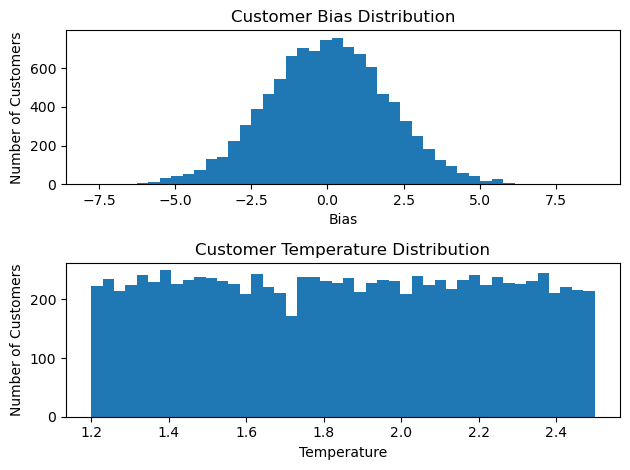

In [8]:
fig, ax = plt.subplots(2)
ax[0].hist(bias, bins="rice")
ax[0].set_title("Customer Bias Distribution")
ax[0].set_xlabel("Bias")
ax[0].set_ylabel("Number of Customers")

ax[1].hist(temperature, bins="rice")
ax[1].set_title("Customer Temperature Distribution")
ax[1].set_xlabel("Temperature")
ax[1].set_ylabel("Number of Customers")
fig.tight_layout()

In [9]:
requests_df = pd.DataFrame({"est_cost": np.random.uniform(5, 20, size)})
prices = requests_df["est_cost"] * 1.1
sd_ratio = 1

In [10]:
config = EnvConfig()
env = RideShareEnv(config=config)

In [11]:
from waymo_agent.data_classes.customer import price_acceptance_probability


prob, z = price_acceptance_probability(cust_df, requests_df, prices.values, sd_ratio, config)

In [12]:
prob.mean()

np.float64(0.5397957585978408)

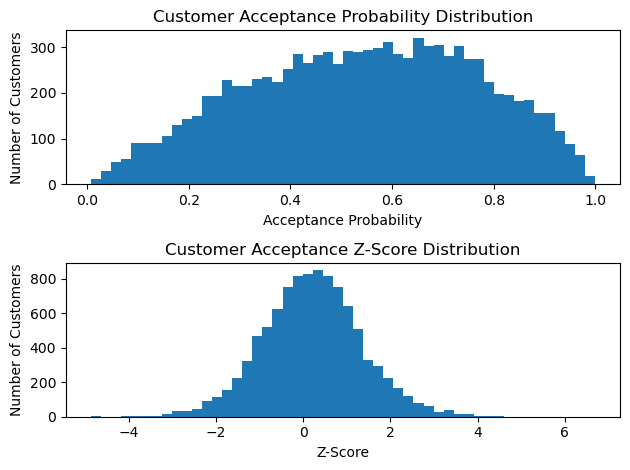

In [13]:
fig, ax = plt.subplots(2)
ax[0].hist(prob, bins=50)
ax[0].set_title("Customer Acceptance Probability Distribution")
ax[0].set_xlabel("Acceptance Probability")
ax[0].set_ylabel("Number of Customers")

ax[1].hist(z, bins=50)
ax[1].set_title("Customer Acceptance Z-Score Distribution")
ax[1].set_xlabel("Z-Score")
ax[1].set_ylabel("Number of Customers")

fig.tight_layout()
plt.show()

In [14]:
env.longest_distance / 1628.34  # miles

11.204419156142428

In [15]:
inspect_graph(env.G)

Graph has 774 nodes and 1613 edges.
Sample node -sample_node_id=1918039877- attributes: {'y': 40.7236015, 'x': -73.9910751, 'street_count': 4, 'lambda': 0.0243, 'x_centered': -929.5667, 'y_centered': -3472.1823, 'x_norm': -0.1298, 'y_norm': -0.4849}

Sample edge attributes: {'osmid': 420809440, 'highway': 'trunk', 'lanes': "('6', '5')", 'maxspeed': 30.0, 'name': 'West Street', 'oneway': True, 'ref': 'NY 9A', 'reversed': False, 'length': 90.23544087615957, 'geometry': <LINESTRING (-74.013 40.714, -74.013 40.715, -74.013 40.715, -74.013 40.715,...>, 'travel_time_minutes': 0.1805}

cls.edge_length_unit='meters', cls.speed_unit='km/h', cls.time_unit='minutes'


In [16]:
env.longest_distance * config.operating_cost_per_km / 1000

18.244603888712962

In [17]:
from waymo_agent.data_classes.customer import CustomerDFGenator


CustomerDFGenator.save()

Saved CustomerDF to /Users/Akseldkw/coding/Columbia/RL-Project/data_sim/customers.parquet
